In [1]:
import pandas as pd
df = pd.read_csv("GO.csv")
df.rename(columns={df.columns[0]: "Gene"}, inplace=True)
print(df.shape)
df.head()


(1124, 8642)


,Gene,GO:0006793,GO:0006796,GO:0008150,GO:0008152,GO:0009987,GO:0044237,GO:0016310,GO:0006464,GO:0006807,...,GO:0036510,GO:0036511,GO:0036512,GO:0007060,GO:0035822,GO:0006311,GO:0043252,GO:0034418,GO:0000733,Class
0,MTOR,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,CR
1,ZMPSTE24,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,NotCR
2,KCNA3,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,CR
3,SHC1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,NotCR
4,LMNA,0,0,1,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,NotCR


In [4]:
genes = df["Gene"].values
labels = df["Class"].map({"CR": 1, "NotCR": 0}).values
X = df.drop(columns=["Gene", "Class"]).values


In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
similarity_matrix = cosine_similarity(X)


In [7]:
import networkx as nx
k = 5  # number of neighbors
G = nx.Graph()
for gene, label in zip(genes, labels):    # Add nodes
    G.add_node(gene, label=label)
for i in range(len(genes)):               # Add edges
    sim_scores = similarity_matrix[i]
    top_k_indices = np.argsort(sim_scores)[-k-1:-1]  # exclude self
    for j in top_k_indices:
        G.add_edge(genes[i], genes[j], weight=sim_scores[j])


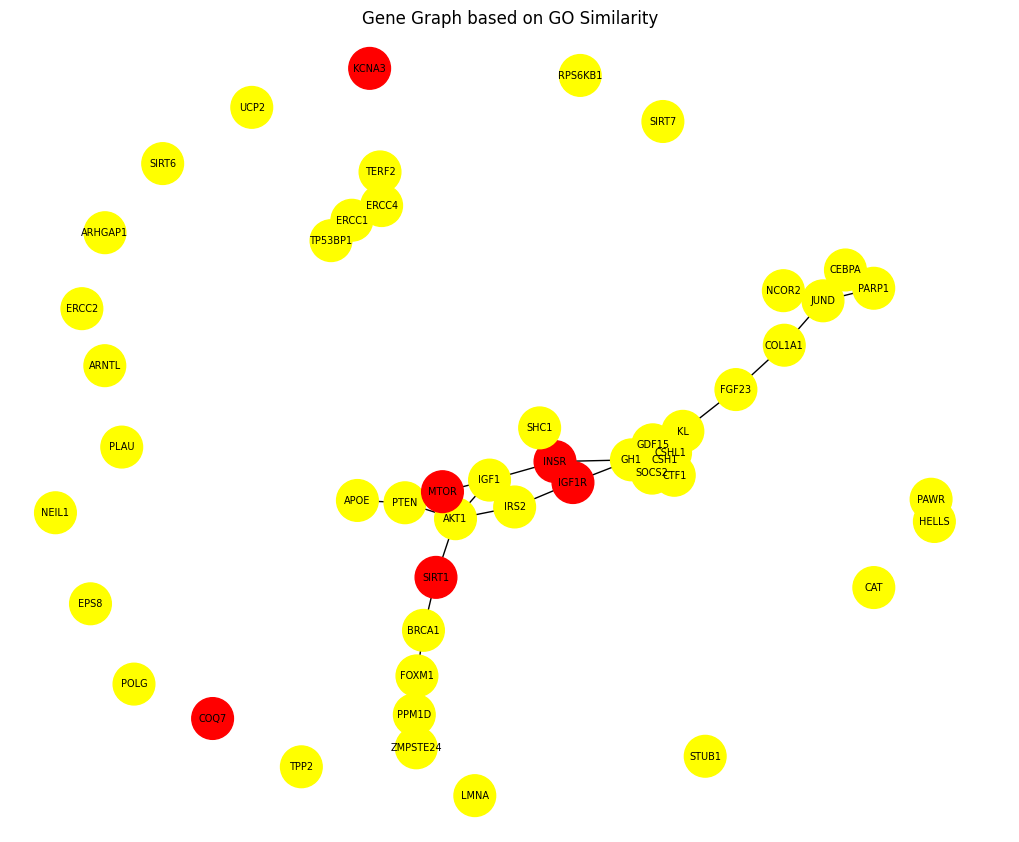

In [14]:
import matplotlib.pyplot as plt
sub_nodes = list(G.nodes())[:50]        # Take a small subset
subgraph = G.subgraph(sub_nodes)
node_colors = [
    "red" if subgraph.nodes[n]["label"] == 1 else "yellow"
    for n in subgraph.nodes()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subgraph, seed=42)
nx.draw(
    subgraph,
    pos,
    node_color=node_colors,
    with_labels=True,
    node_size=900,
    font_size=7)
plt.title("Gene Graph based on GO Similarity")
plt.show()